# Transform footprints into model-ready geometry

Stage 3 handed over real OSM footprints, in degrees, with the buildings around
them. Stage 5 needs closed, convex, metre-scale rooms with windows on the walls
that can have windows. This notebook is the bridge.

Everything here happens in a local metric frame: each city is reprojected to its
own UTM zone and each building is moved so that its bounding box is centred on
the origin. A coordinate is then a metre, and every threshold in this notebook -
a minimum wall length, a clearance, a zone width - can be written as the number
of metres it actually is.

From there the work is geometric. The footprint is simplified, the neighbours
are merged into one occluder, and that occluder decides both what shades the
building and which walls are open enough for windows. The cleaned footprint is
then given a perimeter band, and everything is cut into convex zones.

Buildings drop out along the way: with no wall clear enough for a window, with a
piece that will not come out convex, with a zone too thin to be a room, or with
zones that have ended up in two groups touching nowhere. That is intended. A
model that cannot be simulated sensibly is worse than one fewer building in the
dataset.

**Inputs**

- `data/interim/buildings_gdf.pkl` and `data/interim/neighbors_gdf.pkl` from `BEM4AI_3_Buildings.ipynb`
- `data/interim/city_assets_df.pkl` from `BEM4AI_1_Cities.ipynb`, for the city centres the metric frames come from

**Outputs**

- `data/interim/buildings_transformed.pkl` - the transformed sample and its diagnostics
- `data/interim/selected_bad_building_samples.csv` - the manual review record

Set `BEM4AI_STAGE3_SAMPLE_LIMIT` to transform only the first N samples,
`BEM4AI_STAGE3_APPEND` to add to an existing payload, `BEM4AI_STAGE3_SKIP_EXPORT`
to run without writing, and `BEM4AI_STAGE3_ENABLE_PLOTS=0` to skip the previews.

## Setup

**Steps**

1. Import the stage-4 helpers and resolve the interim paths.
2. Load the Stage 3 sample and the Stage 1 city registry.
3. Apply the append and sample-limit switches, and keep the neighbours in step with the buildings.

**Outputs**
`buildings_gdf`, `neighbors_gdf`, and `city_lookup_df`, the city centres every metric frame is derived from.

Buildings  : 18 rows, 18 samples, crs EPSG:4326
Neighbours : 85 rows
Cities     : 745
Groups     : {'non_residential': 10, 'residential': 8}
Switches   : append=False limit=off skip_export=False plots=True


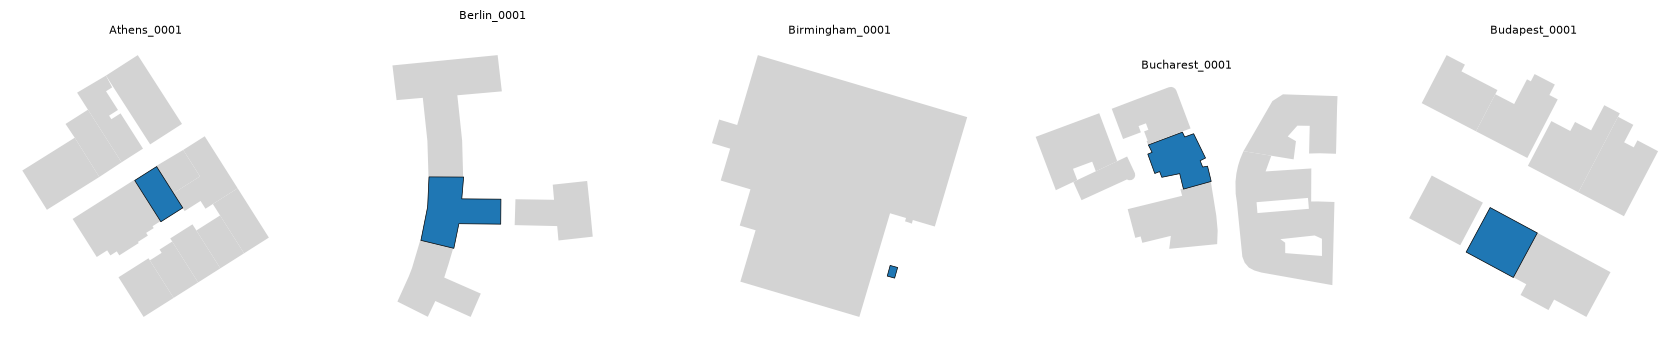

In [1]:
import os

import geopandas as gpd
import pandas as pd

# First: importing it puts the repository root on sys.path, which is what makes
# `scripts.ConvexDecomp` resolve from a notebook.
from helpers.paths import INTERIM_DIR, display_path

from helpers.GHSL_gridplot import preview_samples
from helpers.local_frames import (
    align_neighbour_walls,
    build_local_coordinate_frames,
    city_lookup_from_assets,
    preprocess_local_geometries,
    sync_geometry,
)
from helpers.pickle_compat import read_pickle_compat
from helpers.zone_connectivity import remove_disconnected_buildings
from helpers.shading_and_windows import (
    WindowLimits,
    build_neighbourhood_unions,
    build_rays,
    extract_shading_edges,
    find_window_candidates,
    keep_samples,
    prune_blocked_edges,
    select_final_windows,
)
from helpers.utils import clean_polygonal, ensure_wgs84, keep_polygons_min_area, safe_len
from helpers.zone_quality import ZoneQualityLimits, apply_whole_building_fallback

from scripts.ConvexDecomp.convex_decomposition import AdaptiveSearchConfig
from scripts.ConvexDecomp.decomposition_runner import (
    prepare_decomposition_inputs,
    run_building_decomposition,
)
from scripts.ConvexDecomp.osm_convex_decomposer import ConvexDecompositionConfig
from scripts.ConvexDecomp.osm_footprint_normalizer import (
    FootprintNormalizationConfig,
    LinearArtifactFilterConfig,
)
from scripts.ConvexDecomp.osm_perimeter_builder import (
    PerimeterConfig,
    build_perimeter_zones_for_gdf,
    summarize_perimeter_results,
)
from scripts.ConvexDecomp.osm_perimeter_subdivider import PerimeterSubdivisionConfig
from scripts.ConvexDecomp.polygon_edge_alignment import EdgeAlignmentConfig

BUILDINGS_PKL = INTERIM_DIR / "buildings_gdf.pkl"
NEIGHBORS_PKL = INTERIM_DIR / "neighbors_gdf.pkl"
CITY_ASSETS_PKL = INTERIM_DIR / "city_assets_df.pkl"
TRANSFORMED_PKL = INTERIM_DIR / "buildings_transformed.pkl"

APPEND_TO_EXISTING = os.environ.get("BEM4AI_STAGE3_APPEND", "0") == "1"
SAMPLE_LIMIT = int(os.environ.get("BEM4AI_STAGE3_SAMPLE_LIMIT", "0") or 0)
SKIP_EXPORT = os.environ.get("BEM4AI_STAGE3_SKIP_EXPORT", "0") == "1"
ENABLE_QA_PLOTS = os.environ.get("BEM4AI_STAGE3_ENABLE_PLOTS", "1") == "1"

# Below this, a footprint is not a building, a zone is not a room, and a piece
# of either is a numerical artifact. Every step measures it in square metres.
MIN_AREA_M2 = 2.0
# How far to inflate the merged neighbours before testing what they block.
MASK_EPS = 0.05

# Five panels, one row: enough to see that a step did what it should.
N_SHOW = 5
N_COLS = 5

missing = [path for path in (BUILDINGS_PKL, NEIGHBORS_PKL, CITY_ASSETS_PKL) if not path.exists()]
if missing:
    raise FileNotFoundError(
        f"Missing {', '.join(display_path(path) for path in missing)}. "
        "Run BEM4AI_1_Cities.ipynb and BEM4AI_3_Buildings.ipynb first."
    )

buildings_gdf = ensure_wgs84(read_pickle_compat(BUILDINGS_PKL), "buildings_gdf")
neighbors_gdf = ensure_wgs84(read_pickle_compat(NEIGHBORS_PKL), "neighbors_gdf")
city_assets_df = read_pickle_compat(CITY_ASSETS_PKL)

required_columns = {"sample_id", "city_key", "dataset_kind", "building_type"}
missing_columns = sorted(required_columns - set(buildings_gdf.columns))
if missing_columns:
    raise KeyError(f"buildings_gdf is missing required columns: {missing_columns}")

buildings_gdf["sample_id"] = buildings_gdf["sample_id"].astype(str)
buildings_gdf["city_key"] = buildings_gdf["city_key"].astype(str)
neighbors_gdf["sample_id"] = neighbors_gdf["sample_id"].astype(str)
city_lookup_df = city_lookup_from_assets(city_assets_df)

# In append mode, only the samples the existing payload does not already hold.
if APPEND_TO_EXISTING and TRANSFORMED_PKL.exists():
    done = read_pickle_compat(TRANSFORMED_PKL).get("buildings_m")
    done_ids = set(done["sample_id"].astype(str)) if done is not None else set()
    before = len(buildings_gdf)
    buildings_gdf = buildings_gdf[~buildings_gdf["sample_id"].isin(done_ids)].copy()
    print(f"[Append] Skipping {before - len(buildings_gdf)} samples already in {display_path(TRANSFORMED_PKL)}")

if SAMPLE_LIMIT > 0:
    limited = buildings_gdf["sample_id"].drop_duplicates().head(SAMPLE_LIMIT)
    buildings_gdf = buildings_gdf[buildings_gdf["sample_id"].isin(set(limited))].copy()
    print(f"[Smoke test] Restricted to the first {len(limited)} samples.")

neighbors_gdf = neighbors_gdf[neighbors_gdf["sample_id"].isin(set(buildings_gdf["sample_id"]))].copy()

print(f"Buildings  : {len(buildings_gdf)} rows, {buildings_gdf['sample_id'].nunique()} samples, crs {buildings_gdf.crs}")
print(f"Neighbours : {len(neighbors_gdf)} rows")
print(f"Cities     : {len(city_lookup_df)}")
print(f"Groups     : {buildings_gdf['dataset_kind'].value_counts(dropna=False).to_dict()}")
print(f"Switches   : append={APPEND_TO_EXISTING} limit={SAMPLE_LIMIT or 'off'} skip_export={SKIP_EXPORT} plots={ENABLE_QA_PLOTS}")

# What arrived: the building in blue, the neighbours Stage 3 collected in grey,
# still in degrees. This is the geometry everything below is derived from.
preview_samples(
    buildings_gdf,
    [
        {"gdf": neighbors_gdf, "role": "neighbor", "color": "#d3d3d3"},
        {"gdf": buildings_gdf, "role": "main", "color": "#1f77b4"},
    ],
    n_show=N_SHOW,
    ncols=N_COLS,
    enabled=ENABLE_QA_PLOTS,
);

### Clean every footprint into its own local metric frame

An OSM footprint is traced by hand, in degrees, by whoever happened to map that
building. Before anything can be measured on it, two things have to change: the
units have to become metres, and the tracing noise has to go.

Both happen here, city by city. Each city is reprojected to its own UTM zone and
each building moved so its bounding box is centred on the origin, so a
coordinate is a metre and stays small. The footprints are then normalized -
duplicate vertices, centimetre-long edges, runs of almost-collinear points - and
their walls squared up, within guards that reject any result that changed the
area or moved the outline too far. Neighbours get two extra treatments: they are
squared to their main building's axes rather than their own, so a terrace ends
up on one grid, and the ones that are really fences or retaining walls are
dropped.

What is left is the party walls. A terrace is drawn in OSM as separate
footprints a few centimetres apart, and that gap would later read as a window
opportunity on a shared wall. Every neighbour that still overlaps its building
has its wall projected onto the building's wall line, and whatever projection
cannot close is cut away.

The normalization, alignment and perimeter steps come from the ConvexDecomp
workflow, where `OSM_1_Preprocessing.ipynb` and `OSM_2_Decomposition.ipynb` take
each one apart on its own and show what it does to a footprint. See
*Workflow-Oriented Convex Decomposition of 2D Building Geometry*,
<https://mediatum.ub.tum.de/node?id=1855368>, and `scripts/ConvexDecomp/README.md`.

**Inputs**
`buildings_gdf`, `neighbors_gdf` and `city_lookup_df` from the cell above.

**Steps**

1. Reproject each city to its own UTM zone and translate every sample to its own origin.
2. Normalize the local footprints, then square up walls that are nearly parallel or nearly collinear.
3. Square the neighbours to their main building's axes instead of their own, and drop the ones too long and thin to be buildings.
4. Shrink and re-expand each footprint to erase notches thinner than a metre.
5. Project any neighbour wall that still overlaps its building onto the building's wall line, and cut away what projection cannot close.
6. Keep a shrunken copy of each footprint as the ray target, so a ray aimed at a wall is not counted as blocked by that wall.

**Outputs**
`buildings_m` and `neighbors_m` carrying `geometry_wgs84`, `geometry_metric`,
`geom_local_raw`, `geom_local_preray`, `geom_local` and `metric_crs`,
`geom_shrunk` for the buildings, and `city_metric_crs_map`.

In [2]:
FOOTPRINT_NORMALIZATION_CFG = FootprintNormalizationConfig(
    simplify_tolerance_m=0.2,
    snap_tolerance_m=0.05,
    min_edge_length_m=0.75,
    collinear_distance_tol_m=0.3,
    collinear_angle_tol_deg=10.0,
    # A normalization that changes the area by more than this is rejected.
    area_change_ratio_tol=0.03,
    area_change_m2_tol=3.0,
    max_passes=8,
)

EDGE_ALIGNMENT_CFG = EdgeAlignmentConfig(
    use_angle_families=True,
    family_angle_tol_deg=3.0,
    line_angle_tol_deg=2.0,
    line_offset_tol_m=0.2,
    collinear_tol_deg=1.0,
    min_seg_len_m=0.05,
    # The guards that keep alignment from reshaping a building.
    max_vertex_snap_shift_m=0.4,
    align_min_area_ratio=0.97,
    align_max_area_ratio=1.03,
    align_max_edge_stretch=2.0,
    align_max_hausdorff_m=0.5,
)

# Long and thin enough to be a fence rather than a building.
NEIGHBOR_LINEAR_FILTER_CFG = LinearArtifactFilterConfig(
    hard_min_width_m=2.0,
    hard_min_aspect_ratio=8.0,
    review_min_width_m=3.0,
    review_min_aspect_ratio=6.0,
)

# How close a neighbour has to be before it is squared to the main building.
NEIGHBOR_ALIGN_PROXIMITY_M = 2.0

# Notches thinner than this are mapping artifacts, not architecture.
SHRINK_M = 1.0
EXPAND_M = 1.0

buildings_m, neighbors_m, city_metric_crs_map = build_local_coordinate_frames(
    buildings_gdf,
    neighbors_gdf,
    city_lookup_df,
)

buildings_m = preprocess_local_geometries(
    buildings_m,
    kind_label="Main buildings",
    normalization_cfg=FOOTPRINT_NORMALIZATION_CFG,
    alignment_cfg=EDGE_ALIGNMENT_CFG,
    min_area_m2=MIN_AREA_M2,
)

neighbors_m = preprocess_local_geometries(
    neighbors_m,
    kind_label="Neighbour buildings",
    normalization_cfg=FOOTPRINT_NORMALIZATION_CFG,
    alignment_cfg=EDGE_ALIGNMENT_CFG,
    min_area_m2=MIN_AREA_M2,
    linear_filter_cfg=NEIGHBOR_LINEAR_FILTER_CFG,
    apply_linear_filter=True,
    reference_buildings_gdf=buildings_m,
    proximity_threshold_m=NEIGHBOR_ALIGN_PROXIMITY_M,
)

n_ref = int(neighbors_m["ref_aligned"].sum()) if "ref_aligned" in neighbors_m.columns else 0
print(f"[Neighbour alignment] {n_ref}/{len(neighbors_m)} squared to their main building's axes")

neighbors_m = neighbors_m[neighbors_m["sample_id"].isin(set(buildings_m["sample_id"].astype(str)))].copy()

# Erase the notches, then close the party walls.
buildings_m["geom_local"] = [
    clean_polygonal(geom, SHRINK_M, EXPAND_M, MIN_AREA_M2) for geom in buildings_m["geom_local_preray"].values
]
neighbors_m["geom_local"] = [
    clean_polygonal(geom, SHRINK_M, EXPAND_M, MIN_AREA_M2) for geom in neighbors_m["geom_local_preray"].values
]

n_projected, n_cut, n_changed = align_neighbour_walls(buildings_m, neighbors_m)
if n_changed:
    print(f"[Shared walls] adjusted {n_changed} neighbour(s): {n_projected} projected onto the wall line, {n_cut} cut back")

buildings_m["geom_shrunk"] = [
    None
    if geom is None or getattr(geom, "is_empty", False)
    else keep_polygons_min_area(geom.buffer(-SHRINK_M, join_style=2), MIN_AREA_M2)
    for geom in buildings_m["geom_local"].values
]

for label, gdf in (("Main buildings", buildings_m), ("Neighbours", neighbors_m)):
    keep = gdf["geom_local"].notna() & ~gdf["geom_local"].apply(lambda geom: getattr(geom, "is_empty", True))
    if (~keep).any():
        print(f"[{label}] dropped {int((~keep).sum())} geometries emptied by the cleanup")
    gdf.drop(index=gdf.index[~keep], inplace=True)

neighbors_m = neighbors_m[neighbors_m["sample_id"].isin(set(buildings_m["sample_id"].astype(str)))].copy()
buildings_m = sync_geometry(buildings_m)
neighbors_m = sync_geometry(neighbors_m)

print(f"Cities projected to their own metric CRS: {len(city_metric_crs_map)}")
print("Example assignments:", list(city_metric_crs_map.items())[:5])
print(
    f"Cleaned: buildings={len(buildings_m)} neighbours={len(neighbors_m)} "
    f"with a shrunken copy={buildings_m['geom_shrunk'].notna().sum()}"
)

Project cities to local metric frames: 100%|██████████| 16/16 [00:00<00:00, 157.10it/s]


[Main buildings] rows=18 | normalized=12 | aligned=8 | dropped_empty=0 | dropped_small=0
[Neighbour buildings] dropped hard linear artifacts: 0
[Neighbour buildings] rows=85 | normalized=48 | aligned=56 | dropped_empty=0 | dropped_small=0
[Neighbour alignment] 27/85 squared to their main building's axes
[Shared walls] adjusted 2 neighbour(s): 2 projected onto the wall line, 0 cut back
Cities projected to their own metric CRS: 16
Example assignments: [('Athens', 'EPSG:32634'), ('Berlin', 'EPSG:32633'), ('Birmingham', 'EPSG:32630'), ('Bucharest', 'EPSG:32635'), ('Budapest', 'EPSG:32634')]
Cleaned: buildings=18 neighbours=85 with a shrunken copy=18


## Neighbours

### Merge each neighbourhood into one occluder

Testing rays against neighbour footprints one at a time reports a gap wherever
two of them meet, and in a dense block that is most of the wall. Buffering each
footprint outward, merging, and buffering back closes those seams without
growing the result.

**Outputs**
`buildings_m["neighborhood"]`, one polygon per sample.

In [3]:
# Wide enough to close the seams between footprints drawn as touching.
NEIGHBOUR_SEAM_M = 1.0

neighborhood_map, union_stats = build_neighbourhood_unions(
    buildings_m,
    neighbors_m,
    buffer_m=NEIGHBOUR_SEAM_M,
    min_area_m2=MIN_AREA_M2,
)
buildings_m["neighborhood"] = buildings_m["sample_id"].map(neighborhood_map)

print(f"[Neighbourhood union] samples={buildings_m['sample_id'].nunique()}")
print(f"  with neighbours     : {union_stats['with_neighbors']}")
print(f"  neighbour rows      : {union_stats['total_rows']}")
print(f"  parts               : {union_stats['before_parts']} -> {union_stats['after_parts']}")
print(f"  merged something in : {union_stats['reduced']}/{union_stats['with_neighbors']} samples")

[Neighbourhood union] samples=18
  with neighbours     : 17
  neighbour rows      : 85
  parts               : 85 -> 49
  merged something in : 11/17 samples


### Take the edges that could shade the building

An edge of the merged neighbourhood is a candidate if its outward normal points
at the building, or if it is within `MAX_GAP_M` of it. The distance rule is what
catches a party wall, which is edge-on to the building and therefore scores
nothing on direction alone. Holes are walked as well as shells, so a building in
a courtyard is shaded by the courtyard's inner face.

**Outputs**
`shades_gdf`, one row per candidate edge with its facing score and distance.

Extract neighborhood edges: 100%|██████████| 18/18 [00:00<00:00, 451.38it/s]

[Shading edges] 285 candidates across 17 samples


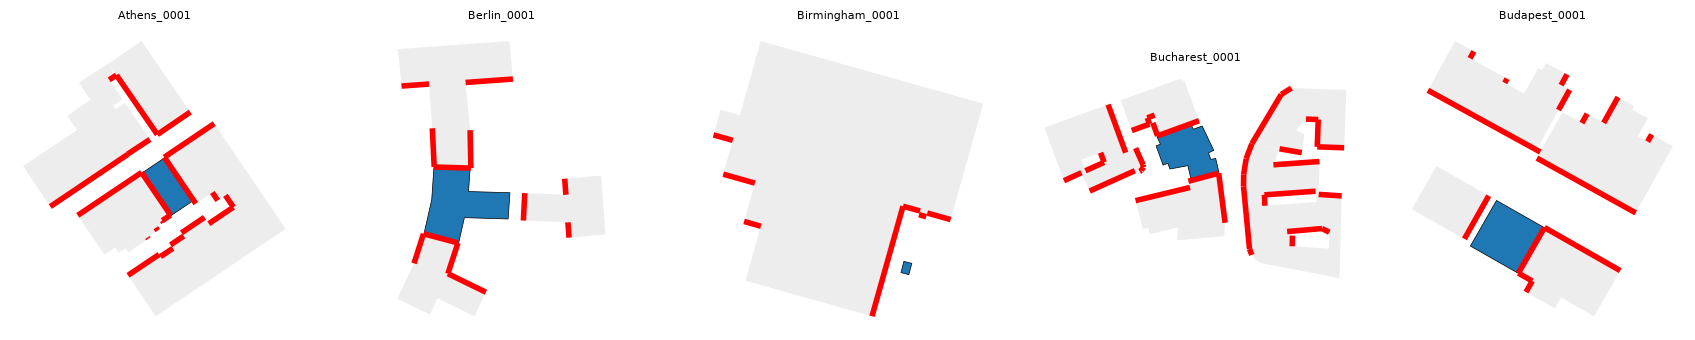

In [4]:
# Close enough to shade even while facing away.
MAX_GAP_M = 0.5

shades_gdf = extract_shading_edges(buildings_m, max_gap_m=MAX_GAP_M)
print(f"[Shading edges] {len(shades_gdf)} candidates across {shades_gdf['sample_id'].nunique()} samples")

preview_samples(
    buildings_m,
    [
        {"gdf": neighbors_m, "column": "geom_local", "role": "neighbor", "color": "#ededed"},
        {"gdf": buildings_m, "column": "geom_local", "role": "main", "color": "#1f77b4"},
        {"gdf": shades_gdf, "role": "edge", "color": "red", "linewidth": 4.0, "zorder": 10},
    ],
    n_show=N_SHOW,
    ncols=N_COLS,
    enabled=ENABLE_QA_PLOTS,
);

### Cast rays from those edges to the building

Points every `INTERVAL_M` along each candidate edge, each joined to the nearest
point on the shrunken footprint. The rays are the evidence the next step uses:
an edge is only really a shading surface if something can get from it to the
building in a straight line.

**Outputs**
`rays_gdf`, plus the sampled points on the edges and on the building.

[Rays] neighbour points=1023 building points=290 rays=1023


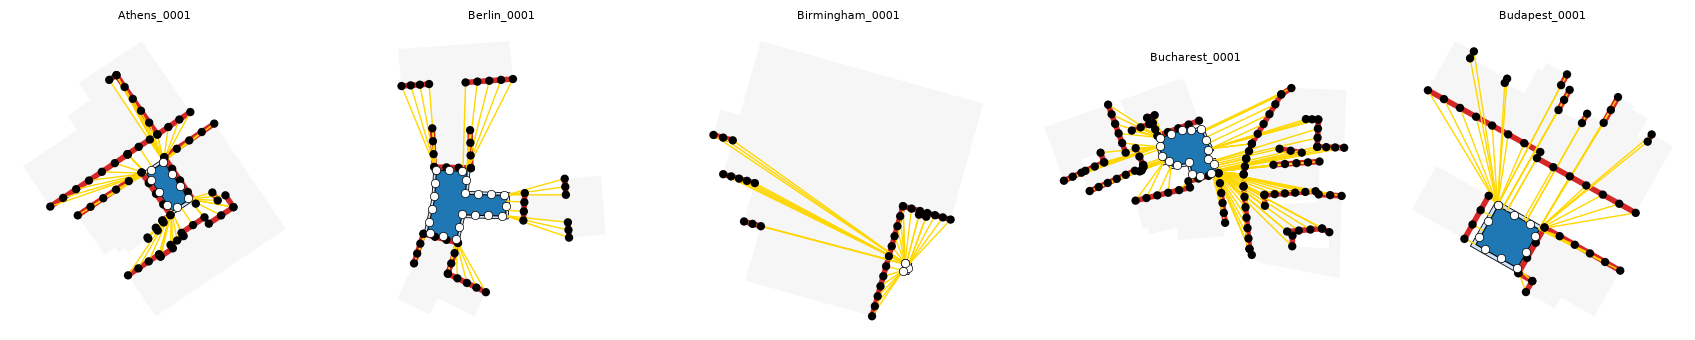

In [5]:
# Sampling step along walls and edges.
INTERVAL_M = 5.0

nei_pts_gdf, main_pts_gdf, rays_gdf = build_rays(buildings_m, shades_gdf, interval_m=INTERVAL_M)
print(f"[Rays] neighbour points={len(nei_pts_gdf)} building points={len(main_pts_gdf)} rays={len(rays_gdf)}")

preview_samples(
    buildings_m,
    [
        {"gdf": buildings_m, "column": "neighborhood", "role": "neighbor",
         "color": "#f6f6f6", "edgecolor": "none", "linewidth": 0.5, "zorder": 0},
        {"gdf": buildings_m, "column": "geom_local", "role": "main",
         "color": "#d0e4ff", "edgecolor": "black", "linewidth": 0.6, "zorder": 4},
        {"gdf": buildings_m, "column": "geom_shrunk", "role": "main",
         "color": "#1f77b4", "edgecolor": "black", "linewidth": 0.8, "zorder": 6},
        {"gdf": shades_gdf, "role": "edge", "color": "#d62728", "linewidth": 4.0, "zorder": 8},
        {"gdf": rays_gdf, "role": "edge", "color": "#ffd700", "linewidth": 1.0, "zorder": 9},
        {"gdf": nei_pts_gdf, "role": "neighbor", "color": "black", "linewidth": 0.5, "zorder": 11},
        {"gdf": main_pts_gdf, "role": "main",
         "color": "white", "edgecolor": "black", "linewidth": 0.5, "zorder": 12},
    ],
    n_show=N_SHOW,
    ncols=N_COLS,
    enabled=ENABLE_QA_PLOTS,
);

### Drop the edges nothing can see

An edge survives if any one of its rays reaches the building through open space.
Rays are trimmed at both ends first: a ray starts on the occluder's own surface
and lands on the building's, so untrimmed every ray registers as blocked.

**Outputs**
`shades_gdf`, reduced to the edges with a clear line of sight.

[Visibility] kept 153 shading edges, removed 132 with no clear ray


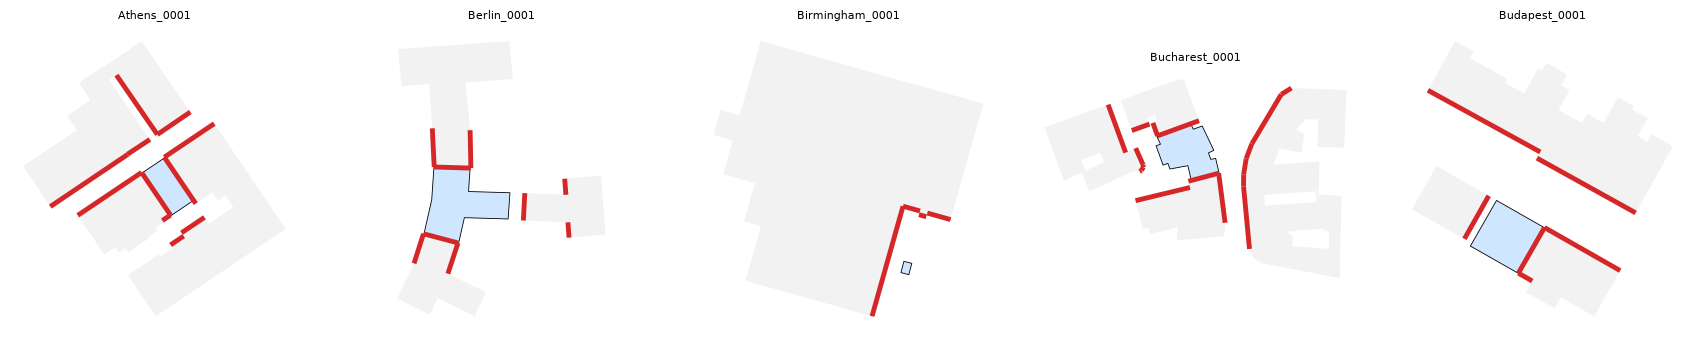

In [6]:
# How much of each ray to ignore at either end, where it touches a surface.
ENDPOINT_TOL = 0.20

shades_gdf, n_blocked = prune_blocked_edges(
    buildings_m,
    shades_gdf,
    rays_gdf,
    endpoint_tol=ENDPOINT_TOL,
    mask_eps=MASK_EPS,
)
print(f"[Visibility] kept {len(shades_gdf)} shading edges, removed {n_blocked} with no clear ray")

preview_samples(
    buildings_m,
    [
        {"gdf": buildings_m, "column": "neighborhood", "role": "neighbor",
         "color": "#f2f2f2", "edgecolor": "none", "linewidth": 0.5, "zorder": 0},
        {"gdf": buildings_m, "column": "geom_local", "role": "main",
         "color": "#cfe6ff", "edgecolor": "black", "linewidth": 0.6, "zorder": 2},
        {"gdf": shades_gdf, "role": "edge", "color": "#d62728", "linewidth": 3.5, "zorder": 5},
    ],
    n_show=N_SHOW,
    ncols=N_COLS,
    enabled=ENABLE_QA_PLOTS,
);

## Windows

### Find the wall stretches that could take a window

A window needs room on two axes: space to the side, so the wall is not pressed
against a neighbour, and space straight ahead, so it looks at something other
than a wall four metres away. Both are measured against the merged neighbours.

A wall is rarely all open or all blocked, so a partly blocked wall is cut into
its open runs and each run becomes a candidate in its own right. `touch_type`
records which rule let a candidate through, which is what to read when a
building's windows look wrong.

Buildings with no candidate at all leave here: without a window there is nothing
to simulate.

**Outputs**
`window_walls_gdf`, and `buildings_m` reduced to the buildings that have one.

[Window candidates] 85 in 17 samples
touch_type
interior_clear    61
corner_only       20
none               4
Dropped 1 buildings with no window candidate; 17 remain


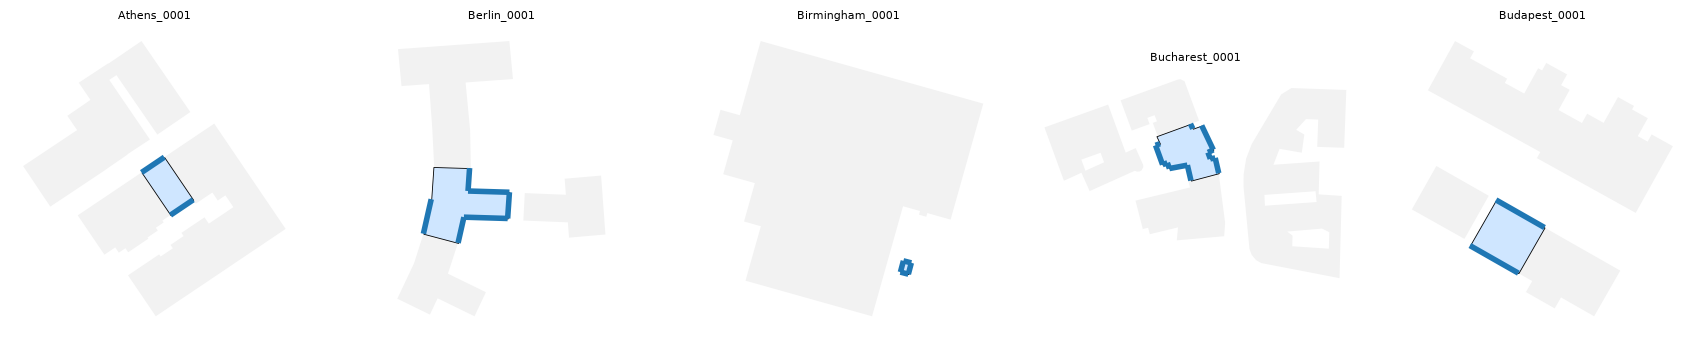

In [7]:
WINDOW_LIMITS = WindowLimits(
    min_wall_len_m=1.0,      # shorter walls are not considered at all
    min_clearance_m=2.0,     # free space required to the side of the wall
    clearance_eps_m=0.01,    # tolerance, so a wall exactly at the limit is not rejected
    touch_eps_m=0.05,        # how close counts as touching the neighbours
    trim_ends_m=0.20,        # ignored at both ends of a wall, where it meets a corner
    min_visible_len_m=1.0,   # shortest open run worth keeping from a partly blocked wall
    min_visible_frac=0.30,   # or this much of the wall, whichever is reached first
    min_front_m=4.0,         # free space required straight out in front
)

window_walls_gdf = find_window_candidates(buildings_m, limits=WINDOW_LIMITS, mask_eps=MASK_EPS)
print(f"[Window candidates] {len(window_walls_gdf)} in {window_walls_gdf['sample_id'].nunique()} samples")
print(window_walls_gdf["touch_type"].value_counts().to_string())

buildings_m, neighbors_m, dropped = keep_samples(
    buildings_m, neighbors_m, set(window_walls_gdf["sample_id"].dropna().unique())
)
if dropped:
    print(f"Dropped {dropped} buildings with no window candidate; {len(buildings_m)} remain")

preview_samples(
    buildings_m,
    [
        {"gdf": buildings_m, "column": "neighborhood", "role": "neighbor",
         "color": "#f2f2f2", "edgecolor": "none", "linewidth": 0.5, "zorder": 0},
        {"gdf": buildings_m, "column": "geom_local", "role": "main",
         "color": "#cfe6ff", "edgecolor": "black", "linewidth": 0.6, "zorder": 2},
        {"gdf": window_walls_gdf, "role": "edge", "color": "#1f77b4", "linewidth": 4.0, "zorder": 8},
    ],
    n_show=N_SHOW,
    ncols=N_COLS,
    enabled=ENABLE_QA_PLOTS,
);

### Choose the windows each building gets

Left alone, a free-standing building would get a window on every wall, which is
not how buildings are built. The cap is a fraction of the building's own long
walls, so it scales with the footprint rather than being a fixed number, and the
longest candidates take the places available.

**Outputs**
`final_windows_gdf`, and `buildings_m` reduced to the buildings that kept one.

[Final windows] 57 windows across 17 samples
      sample_id  bld_edges_all  bld_edges_long  cand_edges_all  cand_edges_long_initial  cand_edges_long_kept  cap_fraction  cap_long_edges
    Athens_0001              4               4               2                        2                     2           0.6               2
    Berlin_0001              9               9               6                        6                     5           0.6               5
Birmingham_0001              4               4               4                        4                     2           0.6               2
 Bucharest_0001             16              15              12                       11                     9           0.6               9
  Budapest_0001              4               4               2                        2                     2           0.6               2
     Essen_0001              8               8               5                        5                     4      

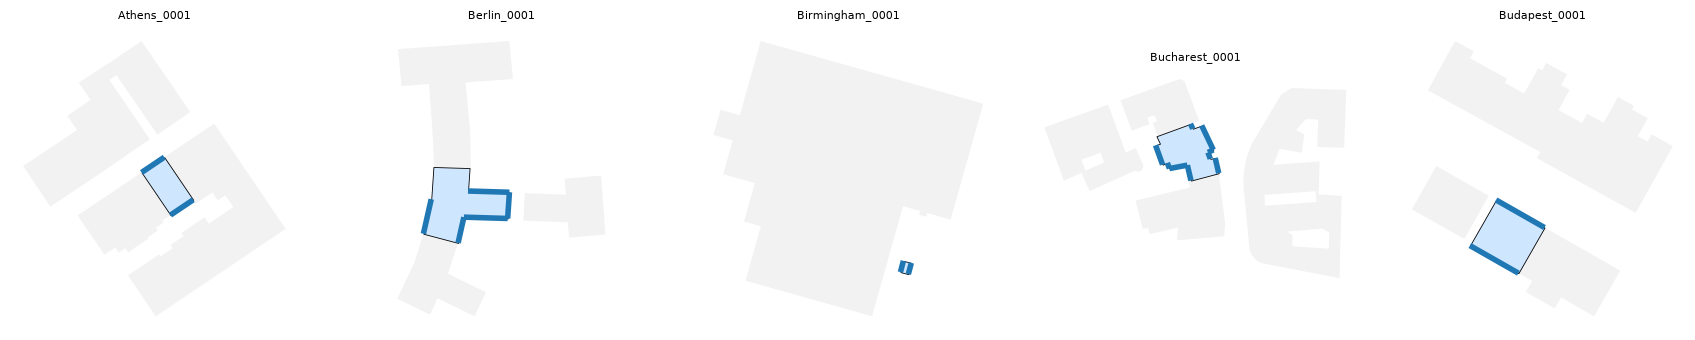

In [8]:
# Only walls at least this long can carry a window,
LONG_MIN_M = 2.0
# and at most this fraction of a building's long walls may do so.
FRACTION_CAP = 0.60

final_windows_gdf, window_summary_df = select_final_windows(
    buildings_m,
    window_walls_gdf,
    long_min_m=LONG_MIN_M,
    fraction_cap=FRACTION_CAP,
)
print(f"[Final windows] {len(final_windows_gdf)} windows across {len(window_summary_df)} samples")
print(window_summary_df.head(10).to_string(index=False))

buildings_m, neighbors_m, dropped = keep_samples(
    buildings_m, neighbors_m, set(final_windows_gdf["sample_id"].dropna().unique())
)
if dropped:
    print(f"Dropped {dropped} buildings left with no window; {len(buildings_m)} remain")

preview_samples(
    buildings_m,
    [
        {"gdf": buildings_m, "column": "neighborhood", "role": "neighbor",
         "color": "#f2f2f2", "edgecolor": "none", "linewidth": 0.5, "zorder": 0},
        {"gdf": buildings_m, "column": "geom_local", "role": "main",
         "color": "#cfe6ff", "edgecolor": "black", "linewidth": 0.6, "zorder": 2},
        {"gdf": final_windows_gdf, "role": "edge", "color": "#1f77b4", "linewidth": 4.0, "zorder": 8},
    ],
    n_show=N_SHOW,
    ncols=N_COLS,
    enabled=ENABLE_QA_PLOTS,
);

## Zones

### Take a perimeter band off each footprint, and keep whatever core is left

Thermal zoning follows daylight and solar gain, so the band of floor within a
few metres of the facade behaves differently from the middle of the building.
The perimeter builder offsets the footprint inward by `perimeter_depth_m`: what
lies outside the offset is the perimeter, and what survives inside is the core.

Most buildings have no core. A footprint narrower than twice the depth leaves
nothing inside the offset and comes out perimeter-only, which is right - a
terraced house four metres deep is all facade. A footprint whose interior
survives but is too small or too thin to be a zone is absorbed back into the
perimeter for the same reason. `perimeter_reason` records which of these
happened.

Smaller still, under `min_input_area_m2`, and the footprint is not split at all:
it keeps no perimeter, and the decomposer later takes it whole.

**Outputs**
`buildings_m` with `perimeter_defined`, `perimeter`, `perimeter_only`,
`perimeter_reason`, `perimeter_geom`, `interior_geom` and `perimeter_parts`,
and `perimeter_summary`.

Perimeter zoning:
  buildings            : 17
  perimeter and core   : 7
  perimeter only       : 10
  not split            : 0
perimeter_only_no_nominal_interior       8
perimeter_with_interior                  7
perimeter_only_all_interiors_absorbed    2


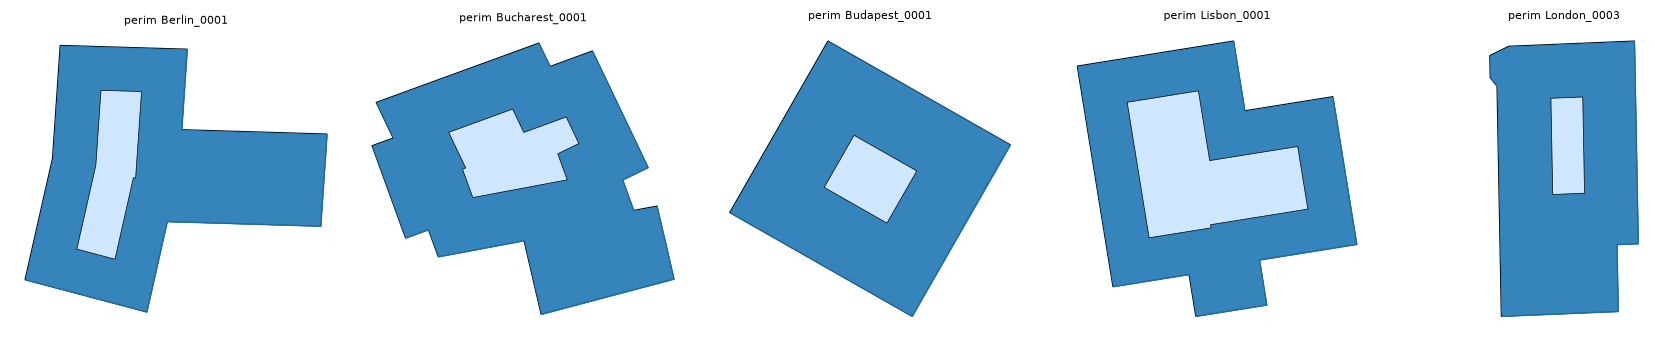

In [9]:
PERIMETER_CFG = PerimeterConfig(
    # How deep the daylit band around the facade is.
    perimeter_depth_m=4.5,
    min_zone_edge_m=2.0,
    min_zone_area_m2=4.0,
    min_interior_area_m2=4.0,
    interior_opening_m=0.5,
    interior_simplify_tolerance_m=0.0,
    min_input_area_m2=MIN_AREA_M2,
    interior_probe_offset_m=0.5,
    interior_min_edge_cleanup_m=0.1,
    simplify_tolerance_m=0.001,
    eps_m=0.01,
    # A perimeter needs contact with the facade on at least this many stretches.
    min_contact_groups=2,
    min_contact_group_length_m=0.5,
    contact_turn_angle_deg=35.0,
    enforce_input_edge_threshold=False,
    split_perimeter_holes=True,
    area_tol=1e-6,
    join_style=2,
    offset_match_angle_tol_deg=5.0,
    offset_match_distance_tol_m=0.5,
)

buildings_m = build_perimeter_zones_for_gdf(buildings_m, geometry_col="geometry", cfg=PERIMETER_CFG)
buildings_m["geom_local"] = buildings_m["geometry"]

perimeter_summary = summarize_perimeter_results(buildings_m)
print("Perimeter zoning:")
print(f"  buildings            : {perimeter_summary['n_total']}")
print(f"  perimeter and core   : {perimeter_summary['n_with_interior']}")
print(f"  perimeter only       : {perimeter_summary['n_perimeter_only']}")
print(f"  not split            : {perimeter_summary['n_no_perimeter_defined']}")
print(pd.Series(perimeter_summary["reason_counts"]).to_string())

preview_samples(
    buildings_m,
    [
        {"gdf": buildings_m, "column": "geom_local", "role": "main",
         "color": "none", "edgecolor": "black", "linewidth": 0.9, "zorder": 1},
        {"gdf": buildings_m, "column": "perimeter_geom", "role": "main",
         "color": "#1f77b4", "edgecolor": "#1f77b4", "linewidth": 0.5, "alpha": 0.9, "zorder": 2},
        {"gdf": buildings_m, "column": "interior_geom", "role": "main",
         "color": "#cfe6ff", "edgecolor": "black", "linewidth": 0.5, "zorder": 3},
    ],
    ids=buildings_m.loc[buildings_m["perimeter"].fillna(False), "sample_id"].dropna().head(N_SHOW).tolist(),
    ncols=N_COLS,
    title_fn=lambda sid, i: f"perim {sid}",
    enabled=ENABLE_QA_PLOTS,
);

### Cut every piece into convex zones

EnergyPlus wants convex zones, so each piece of the building is handed to the
adaptive decomposer separately and the results are reassembled. The pre-check
runs first and carves the obvious trapezoids and corner triangles out of the
perimeter band, which leaves the search a much smaller problem than the whole
ring.

Where the pieces come from depends on what the steps above produced: the
pre-check seeds, or the raw perimeter shells if the pre-check found nothing to
carve, or the whole footprint if there is no perimeter. Whichever route is
taken, the pieces cover the entire building - the core is only ever the
leftover inside a perimeter, so it is never used without one.

A building is kept only if every one of its pieces came out fully convex. Half a
decomposition is not a building, so there is no partial result to keep.

**Outputs**
`buildings_m` with `zones`, `zones_core` and `zones_perim`, and
`polygon_results_gdf` with one diagnostic row per decomposed piece.

Seeds: trapezoid=34 corner=0 remainder=16
Pieces per building: mean 3.35, vertices 17.41


Convex decomposition: 100%|██████████| 17/17 [00:00<00:00, 73.73it/s]


Decomposed 17 buildings into 57 pieces
  dropped, a piece would not go convex : 0
  dropped, outside 1..24 zones           : 0
  remaining                            : 17


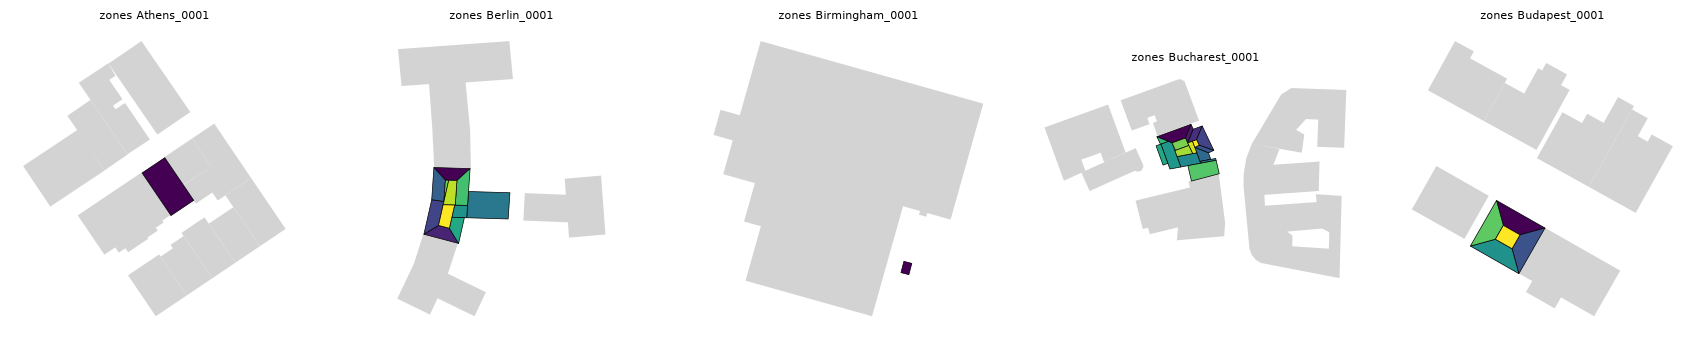

In [10]:
# Carve the easy trapezoids and corner triangles out of the perimeter first.
USE_TRAPEZOID_TRIANGLE_PRECHECK = True
PRECHECK_SUBDIV_CFG = PerimeterSubdivisionConfig(
    min_trapezoid_area_m2=4.0,
    simplify_tolerance_m=0.001,
)

CONVEX_DECOMP_CFG = ConvexDecompositionConfig(
    search_depth=24,
    search_width=4,
    max_reflex_per_node=8,
    max_variants_per_polygon=32,
    max_failed_states=500,
    track_time=True,
    min_area_m2=MIN_AREA_M2,
    # A zoning is scored on how few pieces it has and how square they are.
    weight_parts=1.0,
    weight_compactness=20.0,
    # Start the search shallow and widen it only for the polygons that need it.
    adaptive_search=AdaptiveSearchConfig(
        enabled=True,
        initial_depth=4,
        initial_width=3,
        max_depth=24,
        max_width=4,
        depth_step=1,
        width_step=1,
    ),
)

# Above this a building is over-segmented rather than zoned.
MAX_ZONES_PER_BUILDING = 24

buildings_m, trapezoid_seed_gdf, corner_seed_gdf, remainder_seed_gdf = prepare_decomposition_inputs(
    buildings_m,
    use_precheck=USE_TRAPEZOID_TRIANGLE_PRECHECK,
    precheck_cfg=PRECHECK_SUBDIV_CFG,
)
print(f"Seeds: trapezoid={len(trapezoid_seed_gdf)} corner={len(corner_seed_gdf)} remainder={len(remainder_seed_gdf)}")
print(f"Pieces per building: mean {buildings_m['n_polygons'].mean():.2f}, vertices {buildings_m['n_vertices'].mean():.2f}")

buildings_m, polygon_results_gdf = run_building_decomposition(buildings_m, CONVEX_DECOMP_CFG)

n_before = len(buildings_m)
buildings_m = buildings_m[buildings_m["building_fully_convex"].fillna(False)].copy()
n_failed = n_before - len(buildings_m)

zone_counts = buildings_m["zones"].apply(lambda zones: len(zones) if isinstance(zones, list) else 0)
in_range = zone_counts.between(1, MAX_ZONES_PER_BUILDING)
n_out_of_range = int((~in_range).sum())
buildings_m = buildings_m[in_range].copy()

buildings_m, neighbors_m, _ = keep_samples(buildings_m, neighbors_m, set(buildings_m["sample_id"].astype(str)))
buildings_m = sync_geometry(buildings_m)

print(f"Decomposed {n_before} buildings into {len(polygon_results_gdf)} pieces")
print(f"  dropped, a piece would not go convex : {n_failed}")
print(f"  dropped, outside 1..{MAX_ZONES_PER_BUILDING} zones           : {n_out_of_range}")
print(f"  remaining                            : {len(buildings_m)}")

preview_samples(
    buildings_m,
    [
        {"gdf": neighbors_m, "column": "geom_local", "role": "neighbor", "color": "#d3d3d3"},
        {"gdf": buildings_m, "parts_col": "zones", "role": "main", "cmap": "viridis"},
    ],
    n_show=N_SHOW,
    ncols=N_COLS,
    title_fn=lambda sid, i: f"zones {sid}",
    enabled=ENABLE_QA_PLOTS,
);

### Score the zones, retry what fails, drop what cannot be repaired

Convex is not the same as usable. A zone one metre wide and twenty long solves
perfectly well and is dominated by a surface-to-volume ratio no real room has,
so each building is scored on the shape of its worst zone.

A building carrying a hard failure gets one retry, and only if its trouble is
plausibly the perimeter-and-core split itself: no core was ever found, or the
split produced far too many pieces. Those are decomposed as one whole footprint
instead. The retry is kept only when it scores better than what it replaces, so
a building can never come out worse for having been retried.

Whatever still fails after that leaves the dataset, with its worst zone printed
so the rejection can be checked. This is the last of the automatic checks - the
earlier ones dropped buildings with no window candidates, no final windows, or
a decomposition that would not come out convex. The manual review at the end is
for what none of them can see.

**Inputs**
`buildings_m["zones"]` and `polygon_results_gdf` from the cell above.

**Steps**

1. Score every building on the shape of its worst zone.
2. Retry the hard failures whose zoning was plausibly spoiled by the perimeter split, decomposing the whole footprint instead.
3. Keep a retry only where it scores better than what it replaces.
4. Drop the buildings that still fail, and their neighbours with them.

**Outputs**
`buildings_m` with the `zone_*` metrics and the fallback flags, reduced to the
buildings that can be modelled, and a refreshed `polygon_results_gdf`.

In [11]:
ZONE_QUALITY_LIMITS = ZoneQualityLimits(
    # Unusable: narrow, and either elongated or far from square with it.
    hard_width_m=1.0,
    hard_aspect_ratio=10.0,
    hard_compactness=0.15,
    # Not a verdict: how many zones are unpleasant, which separates two zonings
    # that are otherwise tied when a retry is scored against what it replaces.
    awkward_width_m=1.2,
    awkward_aspect_ratio=8.0,
    awkward_compactness=0.20,
    # Above this a building is over-segmented, which is one of the two reasons
    # its zoning is worth retrying whole.
    oversegmented_zone_count=12,
)

polygon_results_gdf, fallback_summary = apply_whole_building_fallback(
    buildings_m,
    polygon_results_gdf,
    decomp_cfg=CONVEX_DECOMP_CFG,
    quality_limits=ZONE_QUALITY_LIMITS,
    enabled=True,
)

print("[Zone quality]")
print(f"  unusable before the retry : {fallback_summary['hard_fail_before']}")
print(f"  retried                   : {fallback_summary['n_candidates']}")
print(f"  retry was an improvement  : {len(fallback_summary['applied'])}")
print(f"  unusable after            : {fallback_summary['hard_fail_after']}")

# Whatever the retry could not repair cannot be modelled.
unusable = buildings_m[buildings_m["zone_shape_hard_fail"].fillna(False)]
if not unusable.empty:
    print()
    print(f"Dropping {len(unusable)} buildings whose zoning could not be repaired:")
    for _, row in unusable.iterrows():
        print(
            f"  {row['sample_id']:20s} {int(row['zone_count'])} zones, worst is "
            f"{row['zone_width_min_m']:.2f} m wide, aspect {row['zone_aspect_max']:.1f}, "
            f"compactness {row['zone_compactness_min']:.2f}"
        )

buildings_m, neighbors_m, dropped = keep_samples(
    buildings_m, neighbors_m, set(buildings_m.loc[~buildings_m["zone_shape_hard_fail"].fillna(False), "sample_id"])
)
print(f"Buildings remaining: {len(buildings_m)}")

Whole-building fallback: 0it [00:00, ?it/s]

[Zone quality]
  unusable before the retry : 0
  retried                   : 0
  retry was an improvement  : 0
  unusable after            : 0
Buildings remaining: 17


## Export

### Remove buildings whose zones do not form one body

The step above judged each zone on its own shape. This one judges the set. A
building can pass zone by zone and still have ended up in two groups that touch
nowhere - a footprint whose connecting corridor fell below the minimum area, or
an L whose waist the cleanup pinched apart. Every surviving zone is a good room
and the building is still two buildings.

**Outputs**
`buildings_m` and every derived table restricted to the survivors, plus
`buildings_m_bad` holding what was removed and `n_zone_groups` on both.

In [12]:
buildings_m, buildings_m_bad = remove_disconnected_buildings(
    buildings_m,
    # Zones cut from one polygon do not meet exactly, so adjacency is tested on
    # a small buffer; a shared corner is not enough to make one building.
    gap_tol_m=0.05,
    min_shared_edge_m=0.01,
)
if len(buildings_m_bad):
    print(f"Dropping {len(buildings_m_bad)} buildings whose zones fall into separate groups:")
    for _, row in buildings_m_bad.iterrows():
        print(f"  {row['sample_id']:20s} {int(row['zone_count'])} zones in {int(row['n_zone_groups'])} groups")
    preview_samples(
        buildings_m_bad,
        [{"gdf": buildings_m_bad, "parts_col": "zones", "role": "main", "cmap": "viridis"}],
        n_show=N_SHOW,
        ncols=N_COLS,
        title_fn=lambda sid, i: f"rejected {sid}",
        enabled=ENABLE_QA_PLOTS,
    )
print(f"Buildings remaining: {len(buildings_m)}")

valid_ids = set(buildings_m["sample_id"].astype(str))
neighbors_m = neighbors_m[neighbors_m["sample_id"].astype(str).isin(valid_ids)].copy()
shades_gdf = shades_gdf[shades_gdf["sample_id"].astype(str).isin(valid_ids)].copy()
final_windows_gdf = final_windows_gdf[final_windows_gdf["sample_id"].astype(str).isin(valid_ids)].copy()
polygon_results_gdf = polygon_results_gdf[polygon_results_gdf["sample_id"].astype(str).isin(valid_ids)].copy()

Buildings remaining: 17


### Save the transformed payload

Four of these are what `BEM4AI_5_BEMModels.ipynb` and the review app read:
`buildings_m`, `neighbors_m`, `shades_gdf` and `final_windows_gdf`. The other
three are diagnostics kept so that a questionable model can be traced back to
the geometry it came from without re-running the stage.

**Outputs**
`data/interim/buildings_transformed.pkl`.

In [13]:
payload = {
    # What stage 5 and the review app read.
    "buildings_m": buildings_m,
    "neighbors_m": neighbors_m,
    "shades_gdf": shades_gdf,
    "final_windows_gdf": final_windows_gdf,
    # Kept to explain a result, not to build one.
    "buildings_m_bad": buildings_m_bad,
    "perimeter_summary": perimeter_summary,
    "polygon_results_gdf": polygon_results_gdf,
}

if APPEND_TO_EXISTING and TRANSFORMED_PKL.exists():
    existing = read_pickle_compat(TRANSFORMED_PKL)
    for key, value in payload.items():
        previous = existing.get(key)
        if isinstance(previous, pd.DataFrame) and isinstance(value, pd.DataFrame):
            if isinstance(previous, gpd.GeoDataFrame) and isinstance(value, gpd.GeoDataFrame):
                if previous.crs is not None and value.crs is not None and previous.crs != value.crs:
                    value = value.to_crs(previous.crs)
            payload[key] = pd.concat([previous, value], ignore_index=True)
    print(f"[Append] Merged into the existing {display_path(TRANSFORMED_PKL)}")

if SKIP_EXPORT:
    print(f"[Skipped] BEM4AI_STAGE3_SKIP_EXPORT is set; nothing written to {display_path(TRANSFORMED_PKL)}")
else:
    TRANSFORMED_PKL.parent.mkdir(parents=True, exist_ok=True)
    pd.to_pickle(payload, TRANSFORMED_PKL)
    print(f"Wrote {display_path(TRANSFORMED_PKL)}")

for key, value in payload.items():
    print(f"  {key:20s} {type(value).__name__} (len={safe_len(value)})")

Wrote data/interim/buildings_transformed.pkl
  buildings_m          GeoDataFrame (len=17)
  neighbors_m          GeoDataFrame (len=77)
  shades_gdf           GeoDataFrame (len=148)
  final_windows_gdf    GeoDataFrame (len=57)
  buildings_m_bad      GeoDataFrame (len=0)
  perimeter_summary    dict (len=6)
  polygon_results_gdf  GeoDataFrame (len=57)


### Review the transformed buildings

The checks above catch geometry that is wrong on its own terms. They cannot
catch a building that is geometrically fine and still not worth simulating. The
app below shows each transformed building with its neighbours, its shading edges
and its windows, and records the ones to drop.

**Steps**

1. Run the cell and open the link. The server runs in the background, so the cell returns at once.
2. Select the buildings that should not continue to Stage 5, and save in the app.
3. Run the last cell to apply the selection.

Re-running the launch cell restarts the server. The selection is written to
`data/interim/selected_bad_building_samples.csv`.

In [14]:
from helpers.review_app import launch, link

BUILDING_REVIEW_CSV = INTERIM_DIR / "selected_bad_building_samples.csv"

review_url = launch(
    "scripts.review_apps.serve_building_selector",
    transformed_path=TRANSFORMED_PKL,
    csv_path=BUILDING_REVIEW_CSV,
)
print(f"Selections are saved to {display_path(BUILDING_REVIEW_CSV)}")
link(review_url, "Open the building review app")

Selections are saved to data/interim/selected_bad_building_samples.csv


### Apply the review

Run this after saving in the app. With nothing selected it reports that nothing
changed, and it can be run again whenever more buildings are added to the list.

The selected buildings are removed from every sample-indexed table in the
payload together, and kept under `buildings_review_removed` so a removal
can be traced later.

In [15]:
from helpers.review_selections import apply_building_review_selections

review_report = apply_building_review_selections([TRANSFORMED_PKL], BUILDING_REVIEW_CSV)
payload_report = review_report["payloads"][TRANSFORMED_PKL.name]

if not review_report["selected_ids"]:
    print("Nothing is selected for removal; the transformed payload is unchanged.")
elif not payload_report["removed_now"]:
    print("Every saved selection had already been applied.")
else:
    print(
        f"Removed {len(payload_report['removed_now'])} buildings; "
        f"{payload_report['active_buildings']} remain."
    )

if review_report["unknown_ids"]:
    print(f"[WARN] Selected IDs not found in the payload: {review_report['unknown_ids']}")

Nothing is selected for removal; the transformed payload is unchanged.
